# Impacto Fiscal da Isenção de Imposto de Renda para Militares das Forças Armadas

# Introdução

### Atualmente tramita no Senado Federal o Projeto de Lei nº2557/2026, que propõe a isenção total do Imposto de Renda (IRPF) sobre salários, aposentadorias, reservas remuneradas e reformas para todos os militares das Forças Armadas e forças auxiliares, além de ter sido incluída recentemente uma emenda para incluir os policiais civis do DF.

### Nesse contexto, o projeto teve por finalidade analisar o impacto fiscal anual estimado da isenção de IR para os militares das forças armadas, e responder a seguinte pergunta: "Existe algum cenário de isenção do Imposto de Renda para militares das Forças Armadas que apresente menor impacto fiscal para os cofres públicos?"

## Premissas do Projeto

- Utilização apenas os dados de abril/2026;
- Considerado apenas o universo das Forças Armadas federais;
- Não foram incluídas Polícias Militares e Corpos de Bombeiros estaduais;
- Não foram considerados efeitos comportamentais ou mudanças legislativas futuras.

# Coleta de Dados

### A coleta dos dados foi feita através da API do Portal da Transparência do Governo Federal, onde coletei os cadastros e remunerações relativos ao mês de abril de 2026. Foi necessário coletar individualmente os dados dos militares da ativa, dos militares da reserva e reformados, e por fim das pensionistas

In [33]:
import pandas as pd

cadastros = pd.read_csv(
    '/home/archila/Documentos/Meusprojetos/Exercito/Militares/Cadastro.csv',
    sep=';',
    encoding='utf-8',
    usecols=['Id_SERVIDOR_PORTAL', 'DESCRICAO_CARGO', 'ORG_LOTACAO', 'SITUACAO_VINCULO'],
    index_col='Id_SERVIDOR_PORTAL'
    )

cadastros.index.name = 'ID'

salarios = pd.read_csv(
    '/home/archila/Documentos/Meusprojetos/Exercito/Militares/Remuneracao.csv',
    sep=';',
    decimal=',',
    encoding='utf-8',
    index_col='Id_SERVIDOR_PORTAL'
)

salarios.index.name = 'ID'

pensionistas_cadastros = pd.read_csv(
    '/home/archila/Documentos/Meusprojetos/Exercito/Pensionistas/Cadastro_pensionistas.csv',
    sep=';',
    encoding='utf-8',
    usecols=['Id_SERVIDOR_PORTAL', 'DESCRICAO_CARGO_INSTITUIDOR_PENSAO', 'ORG_LOTACAO_INSTITUIDOR_PENSAO', 'SITUACAO_VINCULO'],
    index_col='Id_SERVIDOR_PORTAL'
    )

pensionistas_cadastros.index.name = 'ID'

pensionistas_salarios = pd.read_csv(
    '/home/archila/Documentos/Meusprojetos/Exercito/Pensionistas/Salarios_pensionistas.csv',
    sep=';',
    decimal=',',
    encoding='utf-8',
    index_col='ID'
)

reserva_cadastros = pd.read_csv(
    '/home/archila/Documentos/Meusprojetos/Exercito/ReservaReforma/Cadastro_reserva.csv',
    sep=';',
    encoding='utf-8',
    index_col='ID'
    )

reserva_salarios = pd.read_csv(
    '/home/archila/Documentos/Meusprojetos/Exercito/ReservaReforma/Salarios_reserva.csv',
    sep=';',
    decimal=',',
    encoding='utf-8',
    index_col='ID'
)

# Limpeza dos Dados

### LIMITAÇÕES: Como o Portal da Transparência não apresenta detalhamento completo da composição remuneratória dos militares (adicionais, gratificações, ajuda de custo, indenizações e demais parcelas), os critérios de limpeza adotados concentraram-se em inconsistências objetivamente identificáveis na base de dados, como por exemplo: linhas em que o soldo líquido está negativo ou soldo bruto e IR zerados

### Primeiramente, verifiquei se os registros de cadastros e os de remunerações estavam coerentes, se havia duplicatas ou dados faltosos

In [34]:
(
    cadastros.shape[0],
    salarios.shape[0], 
    cadastros.shape[0] == salarios.shape[0]
)

(358549, 358512, False)

In [35]:
(
    cadastros.index.duplicated().sum(),
    salarios.index.duplicated().sum()
)

(np.int64(37), np.int64(0))

In [36]:
(
    cadastros[cadastros.index.duplicated(keep=False)]
    .sort_values('ID')
    .head(10)
)

,DESCRICAO_CARGO,ORG_LOTACAO,SITUACAO_VINCULO
ID,,,
112625,Guarda-Marinha,Comando da Marinha,MILITAR DA ATIVA
112625,Segundo-Tenente,Comando da Aeronáutica,MILITAR DA ATIVA
341441,Primeiro-Tenente,Comando da Aeronáutica,MILITAR DA ATIVA
341441,Primeiro-Tenente,Comando da Aeronáutica,MILITAR DA ATIVA
431223,Segundo-Tenente,Comando do Exército,MILITAR DA ATIVA
431223,Primeiro-Tenente,Comando da Aeronáutica,MILITAR DA ATIVA
620717,Primeiro-Tenente,Comando da Marinha,MILITAR DA ATIVA
620717,Primeiro-Tenente,Comando do Exército,MILITAR DA ATIVA
657725,Soldado de 1ª Classe/ 2ª Classe,Comando da Aeronáutica,MILITAR DA ATIVA


In [37]:
(
    pensionistas_cadastros.shape[0],
    pensionistas_salarios.shape[0],
    pensionistas_cadastros.shape[0] == pensionistas_salarios.shape[0]
)

(241270, 239116, False)

In [38]:
(
    pensionistas_cadastros.index.duplicated().sum(),
    pensionistas_salarios.index.duplicated().sum()
)

(np.int64(2154), np.int64(0))

In [39]:
(
    pensionistas_cadastros[pensionistas_cadastros.index.duplicated(keep=False)]
    .sort_values('ID')
    .head(10)
)

,DESCRICAO_CARGO_INSTITUIDOR_PENSAO,ORG_LOTACAO_INSTITUIDOR_PENSAO,SITUACAO_VINCULO
ID,,,
148270,Tenente-Brigadeiro-do-Ar,Comando da Aeronáutica,PENSIONISTA
148270,Marechal,Comando do Exército,PENSIONISTA
150225,Segundo-Tenente,Comando da Marinha,PENSIONISTA
150225,Segundo-Sargento,Comando da Marinha,PENSIONISTA
150443,Segundo-Sargento,Comando da Marinha,PENSIONISTA
150443,Primeiro-Tenente,Comando da Marinha,PENSIONISTA
150445,Terceiro-Sargento,Comando da Marinha,PENSIONISTA
150445,Capitão-Tenente,Comando da Marinha,PENSIONISTA
150574,Tenente-Brigadeiro-do-Ar,Comando da Aeronáutica,PENSIONISTA


In [40]:
(
    reserva_cadastros.shape[0],
    reserva_salarios.shape[0],
    reserva_cadastros.shape[0] == reserva_salarios.shape[0]
)

(172137, 172137, True)

In [41]:
(
    reserva_cadastros.index.duplicated().sum(),
    reserva_salarios.index.duplicated().sum()
)

(np.int64(0), np.int64(0))

#### Para remover as duplicatas, Será feito o merge entre cadastros e salários. Como no Merge irá criar duas linhas para o mesmo ID, uma com o cadastro de um posto/graduação e outra com outro posto/graduação, os registros foram agrupados e classificados pelo maior valor de SoldoBruto. Isso fará com que os ID's duplicados fiquem apenas com o maior valor. Um detalhe é que pode ser que o posto/graduação não seja o atualizado, mas para o fim desse projeto que é verificar o impacto fiscal, estar coerente o cargo com o soldo não se faz necessário.

### Criando o merge entre cadastro e salário dos militares da ativa e renomeando colunas

In [42]:
cadastros.columns

Index(['DESCRICAO_CARGO', 'ORG_LOTACAO', 'SITUACAO_VINCULO'], dtype='object')

In [43]:
salarios.columns

Index(['SoldoBruto', 'IR', 'PensaoMIlitar', 'SoldoLiquido'], dtype='object')

In [44]:
ativa = cadastros.merge(salarios, left_index=True, right_index=True)

ativa = (
    ativa
    .sort_values('SoldoBruto', ascending=False)
    .groupby(level=0)
    .first()
)

ativa = ativa.rename(columns={
    'DESCRICAO_CARGO': 'Cargo',
    'ORG_LOTACAO': 'Forca',
    'SITUACAO_VINCULO': 'Situacao',
    'PensaoMIlitar': 'PensaoMilitar'
    })

print(ativa.shape)
print(ativa.head(5))

(358512, 7)
                  Cargo                   Forca          Situacao  SoldoBruto  \
ID                                                                              
1062         Subtenente     Comando do Exército  MILITAR DA ATIVA    14888.77   
1064  Primeiro-Sargento      Comando da Marinha  MILITAR DA ATIVA    12215.52   
1065         Suboficial  Comando da Aeronáutica  MILITAR DA ATIVA    14888.77   
1103            Capitão  Comando da Aeronáutica  MILITAR DA ATIVA    20151.52   
1104         Suboficial  Comando da Aeronáutica  MILITAR DA ATIVA    14888.77   

           IR  PensaoMilitar  SoldoLiquido  
ID                                          
1062 -2508.19       -1563.32      10296.16  
1064 -1892.76       -1282.62       8288.52  
1065 -2448.95       -1563.32      10519.18  
1103 -3948.54       -2115.90      13714.29  
1104 -2627.88       -1563.32      10422.14  


### Criando o merge das pensionistas e renomeando colunas / index

In [45]:
pensionistas_cadastros.columns

Index(['DESCRICAO_CARGO_INSTITUIDOR_PENSAO', 'ORG_LOTACAO_INSTITUIDOR_PENSAO',
       'SITUACAO_VINCULO'],
      dtype='object')

In [46]:
pensionistas_salarios.columns

Index(['SoldoBruto', 'IR', 'PensaoMIlitar', 'SoldoLiquido'], dtype='object')

In [47]:
pensionistas = pensionistas_cadastros.merge(pensionistas_salarios, left_index=True, right_index=True)

pensionistas = (
    pensionistas
    .sort_values('SoldoBruto', ascending=False)
    .groupby(level=0)
    .first()
)

pensionistas = pensionistas.rename(columns = {
    'DESCRICAO_CARGO_INSTITUIDOR_PENSAO': 'Cargo',
    'SITUACAO_VINCULO': 'Situacao',
    'ORG_LOTACAO_INSTITUIDOR_PENSAO': 'Forca',
    'PensaoMIlitar': 'PensaoMilitar'
})

print(pensionistas.shape)
print(pensionistas.head(5))

(239116, 7)
                  Cargo                   Forca     Situacao  SoldoBruto  \
ID                                                                         
1042  Primeiro-Sargento  Comando da Aeronáutica  PENSIONISTA     2739.51   
1768     Vice-Almirante      Comando da Marinha  PENSIONISTA    28482.00   
2808            Capitão     Comando do Exército  PENSIONISTA    19541.20   
3149              Major     Comando do Exército  PENSIONISTA    23610.60   
3645    Cabo (engajado)  Comando da Aeronáutica  PENSIONISTA      794.08   

           IR  PensaoMilitar  SoldoLiquido  
ID                                          
1042     0.00        -369.82       2369.69  
1768 -6101.40       -2990.61      19389.99  
2808 -3216.04       -2638.05      13687.11  
3149 -4184.05       -3187.42      16239.13  
3645     0.00         -97.25        686.51  


### Criando o merge dos militares da reserva renomeando colunas / index

In [48]:
reserva_cadastros.columns

Index(['Cargo', 'Forca', 'Situacao'], dtype='object')

In [49]:
reserva_salarios.columns

Index(['SalarioBruto', 'IR', 'PensaoMilitar', 'SalarioLiquido'], dtype='object')

In [50]:
reserva = reserva_cadastros.merge(reserva_salarios, left_index=True, right_index=True)

reserva = reserva.rename(columns = {
    'SalarioBruto': 'SoldoBruto',
    'SalarioLiquido': 'SoldoLiquido'
})

print(reserva.shape)
print(reserva.head(5))

(172137, 7)
                    Cargo                   Forca            Situacao  \
ID                                                                      
102754   Segundo-Sargento     Comando do Exército  MILITAR DA RESERVA   
2768553           Capitão     Comando do Exército   MILITAR REFORMADO   
2345021   Segundo-Tenente     Comando do Exército  MILITAR DA RESERVA   
92599          Suboficial  Comando da Aeronáutica  MILITAR DA RESERVA   
3425990        Suboficial  Comando da Aeronáutica   MILITAR REFORMADO   

         SoldoBruto       IR  PensaoMilitar  SoldoLiquido  
ID                                                         
102754      8021.86  -853.28        -962.61       5933.24  
2768553    20849.84 -3475.19       -2189.23      14559.93  
2345021    13004.61     0.00       -1560.54      10988.92  
92599      11821.00 -1683.26       -1418.51       8500.55  
3425990    13339.26 -1678.66       -1400.62      10013.21  


### Concatenando ativa, pensionistas e reserva

In [51]:
geral = pd.concat([ativa, pensionistas, reserva])

(
    geral.shape,
    geral.head(10)
)

((769765, 7),
                   Cargo                   Forca          Situacao  SoldoBruto  \
 ID                                                                              
 1062         Subtenente     Comando do Exército  MILITAR DA ATIVA    14888.77   
 1064  Primeiro-Sargento      Comando da Marinha  MILITAR DA ATIVA    12215.52   
 1065         Suboficial  Comando da Aeronáutica  MILITAR DA ATIVA    14888.77   
 1103            Capitão  Comando da Aeronáutica  MILITAR DA ATIVA    20151.52   
 1104         Suboficial  Comando da Aeronáutica  MILITAR DA ATIVA    14888.77   
 1110  Terceiro-Sargento  Comando da Aeronáutica  MILITAR DA ATIVA     6641.43   
 1126  Primeiro-Sargento  Comando da Aeronáutica  MILITAR DA ATIVA    13413.12   
 1130   Segundo-Sargento  Comando da Aeronáutica  MILITAR DA ATIVA     9011.57   
 1133   Segundo-Sargento  Comando da Aeronáutica  MILITAR DA ATIVA     8803.21   
 1140    Tenente-Coronel  Comando da Aeronáutica  MILITAR DA ATIVA    29975.40   
 


### Após concatenar os três registros e fazer a seleção de quais dados duplicados iriam permanecer, comecei a verificar valores inconsistentes e que deveriam ser apagados para não interferir relevantimente na análise

In [52]:
geral.sort_values('SoldoBruto')

,Cargo,Forca,Situacao,SoldoBruto,IR,PensaoMilitar,SoldoLiquido
ID,,,,,,,
3739181,Cabo (engajado),Comando do Exército,MILITAR DA ATIVA,0.00,0.00,0.00,722.03
3941419,"Marinheiro, Soldado Fuzileiro Naval",Comando da Marinha,MILITAR DA ATIVA,0.00,0.00,-8.77,6277.55
2088462,Cabo (engajado),Comando da Aeronáutica,MILITAR DA ATIVA,0.00,0.00,0.00,34069.56
964614,Brigadeiro,Comando da Aeronáutica,MILITAR DA ATIVA,0.00,0.00,0.00,0.00
964617,Capitão-de-Corveta,Comando da Marinha,MILITAR DA ATIVA,0.00,0.00,-2415.54,-2898.64
...,...,...,...,...,...,...,...
3760421,Marechal,Comando do Exército,PENSIONISTA,80165.94,-16171.95,-10224.79,53052.09
3648918,General-de-Exército,Comando do Exército,PENSIONISTA,80696.78,-9972.83,-7139.07,36708.92
2745810,General-de-Exército,Comando do Exército,PENSIONISTA,85880.40,-8505.96,-6347.86,44076.72


In [53]:
SoldoBrutoZero = (geral['SoldoBruto'] == 0 ) & (geral['IR'] == 0)

geral[SoldoBrutoZero]

,Cargo,Forca,Situacao,SoldoBruto,IR,PensaoMilitar,SoldoLiquido
ID,,,,,,,
2270,Primeiro-Sargento,Comando do Exército,MILITAR DA ATIVA,0.0,0.0,0.00,3892.20
2450,Capitão-de-Corveta,Comando da Marinha,MILITAR DA ATIVA,0.0,0.0,-2771.52,-3325.81
3825,Coronel,Comando da Aeronáutica,MILITAR DA ATIVA,0.0,0.0,0.00,0.00
5971,Capitão-de-Mar-e-Guerra,Comando da Marinha,MILITAR DA ATIVA,0.0,0.0,-3526.40,-4143.52
7332,Coronel,Comando do Exército,MILITAR DA ATIVA,0.0,0.0,0.00,0.00
...,...,...,...,...,...,...,...
722310,Segundo-Sargento,Comando do Exército,MILITAR REFORMADO,0.0,0.0,0.00,685.85
1884888,General-de-Brigada,Comando do Exército,MILITAR REFORMADO,0.0,0.0,0.00,4728.18
2985921,Terceiro-Sargento,Comando do Exército,MILITAR REFORMADO,0.0,0.0,0.00,823.60


### Decidi por apagar os militares com SoldoBruto e IR zerados, uma vez que poderiam distorcer os cálculos percentuais relacionados à arrecadação de Imposto de Renda por situação funcional. Não irei apagar os com IR zerado com o bruto acima de 5 mil pois podem haver situações do tipo, como militares inválidos ou com doenças específicas.

## Apagando rows com SoldoBruto zerado

In [54]:
geral = geral[~SoldoBrutoZero]

In [55]:
geral

,Cargo,Forca,Situacao,SoldoBruto,IR,PensaoMilitar,SoldoLiquido
ID,,,,,,,
1062,Subtenente,Comando do Exército,MILITAR DA ATIVA,14888.77,-2508.19,-1563.32,10296.16
1064,Primeiro-Sargento,Comando da Marinha,MILITAR DA ATIVA,12215.52,-1892.76,-1282.62,8288.52
1065,Suboficial,Comando da Aeronáutica,MILITAR DA ATIVA,14888.77,-2448.95,-1563.32,10519.18
1103,Capitão,Comando da Aeronáutica,MILITAR DA ATIVA,20151.52,-3948.54,-2115.90,13714.29
1104,Suboficial,Comando da Aeronáutica,MILITAR DA ATIVA,14888.77,-2627.88,-1563.32,10422.14
...,...,...,...,...,...,...,...
2883671,General-de-Brigada,Comando do Exército,MILITAR REFORMADO,31506.09,-5853.64,-3308.13,21399.14
2756562,Capitão,Comando do Exército,MILITAR DA RESERVA,24141.92,-4734.44,-2897.02,15786.21
628258,Segundo-Sargento,Comando do Exército,MILITAR REFORMADO,10784.59,0.00,-1132.38,9285.55


## Prosseguindo na Análise

In [56]:
geral.sort_values('SoldoBruto')

,Cargo,Forca,Situacao,SoldoBruto,IR,PensaoMilitar,SoldoLiquido
ID,,,,,,,
4098164,Segundo-Tenente,Comando da Marinha,MILITAR DA ATIVA,0.00,-194.51,0.00,5559.98
897708,Segundo-Tenente,Comando da Aeronáutica,MILITAR DA ATIVA,0.00,-339.65,0.00,7174.27
3610462,Demais Pensionistas,Comando do Exército,PENSIONISTA,0.00,-68.37,0.00,-68.37
3627280,Demais Pensionistas,Comando do Exército,PENSIONISTA,0.00,-137.50,0.00,-137.50
1906987,Segundo-Tenente,Comando do Exército,MILITAR DA ATIVA,0.00,-676.86,-725.68,5301.36
...,...,...,...,...,...,...,...
3760421,Marechal,Comando do Exército,PENSIONISTA,80165.94,-16171.95,-10224.79,53052.09
3648918,General-de-Exército,Comando do Exército,PENSIONISTA,80696.78,-9972.83,-7139.07,36708.92
2745810,General-de-Exército,Comando do Exército,PENSIONISTA,85880.40,-8505.96,-6347.86,44076.72


In [57]:
SoldoIncoerente = (
    (geral['SoldoBruto'] < 5000) &
    (geral['IR'] < 0)
)

In [58]:
geral[SoldoIncoerente].sort_values('SoldoBruto', ascending = False).head(30)

,Cargo,Forca,Situacao,SoldoBruto,IR,PensaoMilitar,SoldoLiquido
ID,,,,,,,
4237991,Primeiro-Sargento,Comando da Aeronáutica,PENSIONISTA,4970.04,-317.68,-670.95,3981.41
4247260,Primeiro-Sargento,Comando da Aeronáutica,PENSIONISTA,4970.04,-829.54,-670.95,3469.55
4247437,Segundo-Sargento,Comando da Marinha,PENSIONISTA,4948.54,-1657.11,-735.34,7673.24
944512,Terceiro-Sargento,Comando do Exército,PENSIONISTA,4941.67,-918.67,-1037.74,2688.77
4248057,Primeiro-Sargento,Comando da Aeronáutica,PENSIONISTA,4940.10,-534.34,-666.91,3738.85
4198858,Primeiro-Sargento,Comando da Aeronáutica,PENSIONISTA,4940.10,-534.34,-666.91,3738.85
3031185,Primeiro-Sargento,Comando da Marinha,PENSIONISTA,4930.10,-1312.42,-1357.51,10936.89
122805,Primeiro-Tenente,Comando da Aeronáutica,MILITAR DA ATIVA,4923.46,-448.71,0.00,152810.08
4166617,Capitão,Comando do Exército,PENSIONISTA,4913.18,-1793.22,-4223.08,27648.63


In [59]:
geral[SoldoIncoerente].sort_values('SoldoBruto', ascending = False).shape

(3146, 7)

In [60]:
SoldoLiquidoNegativo = (
    (geral['SoldoBruto'] < 1000) &
    (geral['Situacao'] != "PENSIONISTA") &
    (geral['IR'] < 0) &
    (geral['SoldoLiquido'] < 0)
)

geral[SoldoLiquidoNegativo].sort_values('SoldoLiquido')
    

,Cargo,Forca,Situacao,SoldoBruto,IR,PensaoMilitar,SoldoLiquido
ID,,,,,,,
246467,Capitão-de-Mar-e-Guerra,Comando da Marinha,MILITAR DA ATIVA,0.0,-1070.56,-3746.21,-12621.40
559451,Capitão-de-Corveta,Comando da Marinha,MILITAR DA ATIVA,0.0,-223.12,-2898.65,-12367.20
3276953,Capitão-de-Corveta,Comando da Marinha,MILITAR DA ATIVA,0.0,-89.89,-2415.54,-10454.91
2106608,Capitão-de-Corveta,Comando da Marinha,MILITAR DA ATIVA,0.0,-745.41,-2844.84,-10363.69
2503737,Primeiro-Tenente,Comando da Marinha,MILITAR DA ATIVA,0.0,-88.76,-1607.21,-5192.87
3459274,Primeiro-Tenente,Comando da Marinha,MILITAR DA ATIVA,0.0,-1625.41,0.00,-2181.48
1684835,Terceiro-Sargento,Comando do Exército,MILITAR DA ATIVA,0.0,-122.33,-568.75,-417.17


In [61]:
geral = geral[~SoldoLiquidoNegativo]

### Embora alguns registros apresentem características atípicas, optou-se por mantê-los na base, pois não foi possível concluir objetivamente que se tratavam de inconsistências.

### Porém, foram excluídos 7 militares que estavam com o soldo líquido negativo, registros potencialmente inconsistentes. Considerando as regras aplicáveis aos descontos incidentes sobre a remuneração militar, esses casos foram classificados como potenciais inconsistências da base de dados. A exclusão desses casos representa aproximadamente a 4 mil reais por mês em arrecadação de Imposto de Renda, equivalente a apenas 0,00046% da arrecadação mensal analisada, não alterando de forma material os resultados ou as conclusões do projeto.

In [62]:
geral[(geral['IR'] < 0) & (geral['SoldoLiquido'] <= 0) & (geral['Situacao'] == 'PENSIONISTA')].sort_values("IR", ascending = False)

,Cargo,Forca,Situacao,SoldoBruto,IR,PensaoMilitar,SoldoLiquido
ID,,,,,,,
3217638,Segundo-Sargento,Comando da Aeronáutica,PENSIONISTA,3090.34,-4.07,-417.19,-2465.69
3610462,Demais Pensionistas,Comando do Exército,PENSIONISTA,0.00,-68.37,0.00,-68.37
2789322,Demais Pensionistas,Comando do Exército,PENSIONISTA,0.00,-70.41,0.00,-70.41
3162635,Demais Pensionistas,Comando do Exército,PENSIONISTA,0.00,-70.41,0.00,-70.41
848578,Demais Pensionistas,Comando do Exército,PENSIONISTA,0.00,-124.91,0.00,-124.91
...,...,...,...,...,...,...,...
4247414,Suboficial,Comando da Aeronáutica,PENSIONISTA,12935.04,-34375.50,-1358.17,-14758.19
3929068,Primeiro-Sargento,Comando da Aeronáutica,PENSIONISTA,8862.23,-37082.90,1473.66,-13579.57
3137513,Brigadeiro,Comando da Aeronáutica,PENSIONISTA,29682.37,-66015.46,-3116.64,-16181.00


In [63]:
PensionistasIncoerentes = (
    (geral['IR'] < 0) &
    (geral['SoldoLiquido'] <= 0) &
     (geral['Situacao'] == 'PENSIONISTA')
)

PensionistasIncoerentes

ID
1062       False
1064       False
1065       False
1103       False
1104       False
           ...  
2883671    False
2756562    False
628258     False
2625220    False
2728578    False
Length: 760760, dtype: bool

In [64]:
geral[(geral['IR'] < 0) & (geral['SoldoLiquido'] <= 0) & (geral['Situacao'] == 'PENSIONISTA')].sort_values('SoldoBruto', ascending=False)['IR'].sum().round(2) * 12

np.float64(-19142293.32)

In [65]:
geral = geral[~PensionistasIncoerentes]

### Foram removidos 193 registros de pensionistas com soldo líquido negativo, representando aproximadamente 0,03% da base e alterando o resultado final em cerca de R$ 19 milhões anuais.

In [66]:
geral

,Cargo,Forca,Situacao,SoldoBruto,IR,PensaoMilitar,SoldoLiquido
ID,,,,,,,
1062,Subtenente,Comando do Exército,MILITAR DA ATIVA,14888.77,-2508.19,-1563.32,10296.16
1064,Primeiro-Sargento,Comando da Marinha,MILITAR DA ATIVA,12215.52,-1892.76,-1282.62,8288.52
1065,Suboficial,Comando da Aeronáutica,MILITAR DA ATIVA,14888.77,-2448.95,-1563.32,10519.18
1103,Capitão,Comando da Aeronáutica,MILITAR DA ATIVA,20151.52,-3948.54,-2115.90,13714.29
1104,Suboficial,Comando da Aeronáutica,MILITAR DA ATIVA,14888.77,-2627.88,-1563.32,10422.14
...,...,...,...,...,...,...,...
2883671,General-de-Brigada,Comando do Exército,MILITAR REFORMADO,31506.09,-5853.64,-3308.13,21399.14
2756562,Capitão,Comando do Exército,MILITAR DA RESERVA,24141.92,-4734.44,-2897.02,15786.21
628258,Segundo-Sargento,Comando do Exército,MILITAR REFORMADO,10784.59,0.00,-1132.38,9285.55


In [67]:
geral[(geral['IR'] < 0) & (geral['SoldoLiquido'] <= 0) & (geral['Situacao'] == 'MILITAR DA RESERVA')].sort_values("IR", ascending = False)

,Cargo,Forca,Situacao,SoldoBruto,IR,PensaoMilitar,SoldoLiquido
ID,,,,,,,
40792,Capitão-de-Mar-e-Guerra,Comando da Marinha,MILITAR DA RESERVA,29386.75,-2251.22,-3085.60,-14374.14
1394029,Suboficial,Comando da Marinha,MILITAR DA RESERVA,15225.62,-2633.91,-1598.69,-122123.28
2939503,Capitão,Comando da Aeronáutica,MILITAR DA RESERVA,25244.40,-5033.66,-2650.66,-127983.57


In [68]:
ReservaIncoerentes = (
    (geral['IR'] < 0) &
    (geral['SoldoLiquido'] <= 0) &
     (geral['Situacao'] == 'MILITAR DA RESERVA')
)

In [69]:
geral = geral[~ReservaIncoerentes]

In [70]:
geral[(geral['IR'] < 0) & (geral['SoldoLiquido'] <= 0) & (geral['Situacao'] == 'MILITAR REFORMADO')].sort_values("IR", ascending = False)

,Cargo,Forca,Situacao,SoldoBruto,IR,PensaoMilitar,SoldoLiquido
ID,,,,,,,


### Fiz o mesmo com os militares da reserva. Reformados não haviam nesse caso

# Análise dos Dados

 ### Para a análise, primeiro agrupei por situação a quantidade total de milares, o total do soldo bruto, a média salarial daquele grupo, o total de IR pago por eles e o total de pensão militar pago, com o objetivo de obter uma visão consolidada da distribuição da remuneração e da arrecadação de Imposto de Renda entre os diferentes grupos analisados. Após isso, criei a função de simulação para insenção através de cenários, onde foram cinco no total: Iseneção total (o que está tramitando no Senado Federal), Isenção para todos os militares da ativa, e isenção para todos os militares da ativa dentro das seguintes faixas de soldo bruto: 20 mil, 15 mil e 10 mil reais

### Agrupando despesa mensal por situação (ativa, reserva, reforma e pensionista)

In [71]:
resumo = geral.groupby('Situacao').agg(
    Quantidade=('SoldoBruto', 'count'),
    TotalBruto=('SoldoBruto', 'sum'),
    MediaBruta=('SoldoBruto', 'mean'),
    TotalIR=('IR', 'sum'),
    TotalPensao=('PensaoMilitar', 'sum')
).round(2)

# Adiciona linha de total antes de formatar
resumo.loc['TOTAL'] = [
    resumo['Quantidade'].sum(),
    resumo['TotalBruto'].sum(),
    geral['SoldoBruto'].mean(),
    resumo['TotalIR'].sum(),
    resumo['TotalPensao'].sum()
]

# Agora formata
resumo_fmt = resumo.copy()

for col in ['TotalBruto', 'MediaBruta', 'TotalIR', 'TotalPensao']:
    resumo_fmt[col] = resumo_fmt[col].map(
        lambda x: f'R$ {x:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.')
    )

resumo_fmt['Quantidade'] = resumo_fmt['Quantidade'].map(
    lambda x: f'{x:,.0f}'.replace(',', '.')
)

resumo_fmt

,Quantidade,TotalBruto,MediaBruta,TotalIR,TotalPensao
Situacao,,,,,
MILITAR DA ATIVA,349.615,"R$ 2.380.006.161,15","R$ 6.807,51","R$ -313.316.705,62","R$ -251.881.193,02"
MILITAR DA RESERVA,80.816,"R$ 1.399.546.639,31","R$ 17.317,69","R$ -222.474.092,82","R$ -159.085.172,02"
MILITAR REFORMADO,91.295,"R$ 1.221.332.105,22","R$ 13.377,86","R$ -99.086.942,05","R$ -141.787.283,40"
PENSIONISTA,238.838,"R$ 2.182.167.610,88","R$ 9.136,60","R$ -224.011.707,99","R$ -271.654.227,34"
TOTAL,760.564,"R$ 7.183.052.516,56","R$ 9.444,38","R$ -858.889.448,48","R$ -824.407.875,78"


## Criando Função de Isenção de IR Por Cenários

In [72]:
def simular_isencao(df, teto_bruto=None, situacoes=None, label='Cenário'):
    """
    Simula o impacto fiscal de isentar IR por faixa de SoldoBruto e/ou Situacao.
    
    Parâmetros:
        teto_bruto  : float ou None — se None, isenta todos independente de bruto
        situacoes   : list ou None — ex: ['MILITAR DA ATIVA'], se None inclui todos
        label       : str — nome do cenário para exibição
    
    Retorna:
        dict ccom impacto_mensal, impacto_anual, n_beneficiados, pct_do_total
    """
    filtro = pd.Series([True] * len(df), index=df.index)
    
    if teto_bruto is not None:
        filtro &= df['SoldoBruto'] <= teto_bruto
    if situacoes is not None:
        filtro &= df['Situacao'].isin(situacoes)
    
    isentos = df[filtro]
    impacto_mensal = abs(isentos['IR'].sum())
    total_IR = abs(df['IR'].sum())
    
    return {
        'label': label,
        'n_beneficiados': len(isentos),
        'impacto_mensal': impacto_mensal,
        'impacto_anual': impacto_mensal * 12,
        'pct_do_total': impacto_mensal / total_IR * 100
    }

In [73]:
cenarios = [
    simular_isencao(geral, label='Proposta no Senado (todos)'),
    simular_isencao(geral, situacoes=['MILITAR DA ATIVA'], label='Somente Ativa'),
    simular_isencao(geral, teto_bruto=20000, situacoes=['MILITAR DA ATIVA'], label='Ativa até R$20k'),
    simular_isencao(geral, teto_bruto=15000, situacoes=['MILITAR DA ATIVA'], label='Ativa até R$15k'),
    simular_isencao(geral, teto_bruto=10000, situacoes=['MILITAR DA ATIVA'], label='Ativa até R$10k')
]

def formatar_brl(valor):
    return f"{valor:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

for c in cenarios:
    print(
        f"{c['label']:<35} | "
        f"Beneficiados: {c['n_beneficiados']:>10.0f} | "
        f"Impacto anual: R$ {formatar_brl(c['impacto_anual']):>18} | "
        f"% do IR total: {c['pct_do_total']:>5.1f}%"
    )

Proposta no Senado (todos)          | Beneficiados:     760564 | Impacto anual: R$  10.306.673.381,76 | % do IR total: 100.0%
Somente Ativa                       | Beneficiados:     349615 | Impacto anual: R$   3.759.800.467,44 | % do IR total:  36.5%
Ativa até R$20k                     | Beneficiados:     332366 | Impacto anual: R$   2.702.768.297,40 | % do IR total:  26.2%
Ativa até R$15k                     | Beneficiados:     313974 | Impacto anual: R$   2.002.854.683,76 | % do IR total:  19.4%
Ativa até R$10k                     | Beneficiados:     255330 | Impacto anual: R$     605.453.539,92 | % do IR total:   5.9%


## Importando plotly e Gerando Gráfico a Partir dos Cenários

In [74]:
import plotly.graph_objects as go

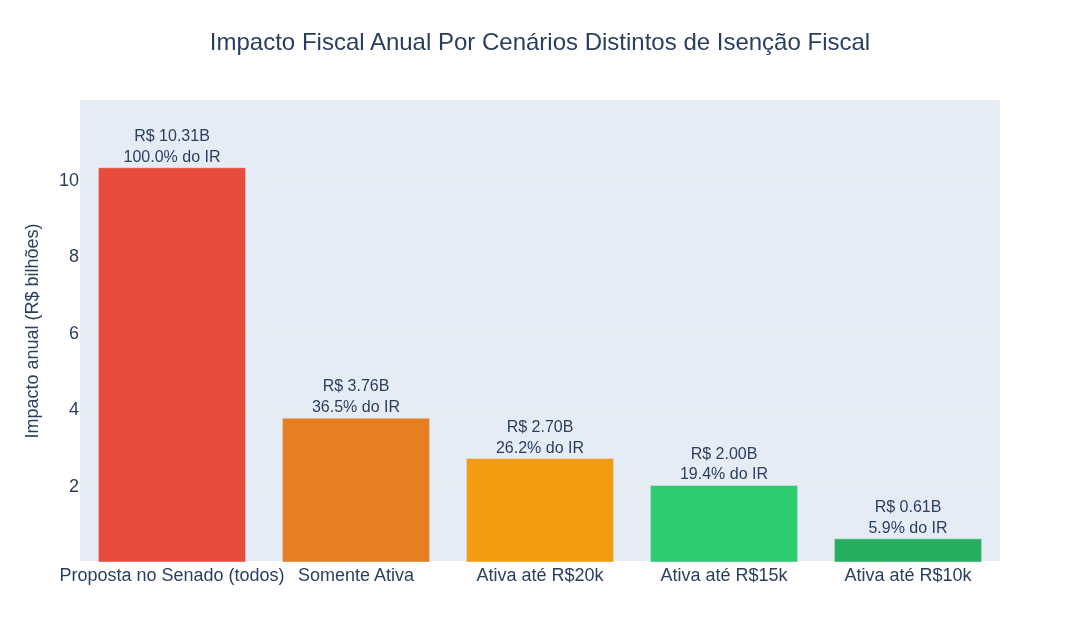

In [75]:
resultados = pd.DataFrame(cenarios)
resultados['impacto_anual_bi'] = resultados['impacto_anual'] / 1e9

fig = go.Figure(go.Bar(
    x=resultados['label'],
    y=resultados['impacto_anual_bi'],
    text=[f'R$ {v:.2f}B<br>{p:.1f}% do IR' 
          for v, p in zip(resultados['impacto_anual_bi'], resultados['pct_do_total'])],
    textposition='outside',
    marker_color=['#e74c3c', '#e67e22', '#f39c12', '#2ecc71', '#27ae60']
))

fig.update_layout(
    title='Impacto Fiscal Anual Por Cenários Distintos de Isenção Fiscal',
    title_font=dict(size=24),
    title_x=0.5,

    xaxis_title='',
    yaxis_title='Impacto anual (R$ bilhões)',

    font=dict(size=16),
    
    xaxis=dict(
        tickfont=dict(size=18)
    ),

    yaxis=dict(
        gridcolor='#eeeeee',
        tickfont=dict(size=18),
        title_font=dict(size=18),
        tickvals=[2, 4, 6, 8, 10]
    ),

    width=1200,
    height=627
)

fig.show()

# Conclusão

### A análise dos dados de remuneração de abril/2026, abrangendo aproximadamente 760 mil militares das Forças Armadas, indica que a isenção total do IR proposta pelo PL nº 2557/2026 geraria uma renúncia fiscal estimada de **R$ 10,3 bilhões anuais**.

### Os cenários alternativos avaliados demonstram que o impacto fiscal varia de forma expressiva conforme os critérios de elegibilidade adotados:




In [84]:
resultados = pd.DataFrame(cenarios)
resultados['impacto_anual_bi'] = (resultados['impacto_anual'] / 1e9).map(lambda x: f"R$ {x:.2f} Bi".replace('.', ','))
resultados['pct_do_total'] = resultados['pct_do_total'].map(lambda x: f"{x:.1f}%".replace('.', ','))
resultados['n_beneficiados'] = resultados['n_beneficiados'].map(lambda x: f"{x:,.0f}".replace(',', '.'))

resultados[['label', 'n_beneficiados', 'impacto_anual_bi', 'pct_do_total']].rename(columns={
    'label': 'Cenário',
    'n_beneficiados': 'Beneficiados',
    'impacto_anual_bi': 'Impacto Anual',
    'pct_do_total': '% da Proposta Original'
}).set_index('Cenário')

,Beneficiados,Impacto Anual,% da Proposta Original
Cenário,,,
Proposta no Senado (todos),760.564,"R$ 10,31 Bi","100,0%"
Somente Ativa,349.615,"R$ 3,76 Bi","36,5%"
Ativa até R$20k,332.366,"R$ 2,70 Bi","26,2%"
Ativa até R$15k,313.974,"R$ 2,00 Bi","19,4%"
Ativa até R$10k,255.330,"R$ 0,61 Bi","5,9%"


### Restringir a isenção aos militares da ativa já reduziria o impacto fiscal em 63,5% em relação à proposta original. A adoção de um teto de R$ 10.000 de soldo bruto limitaria o custo a apenas 5,9% da proposta, beneficiando 255 mil militares, concentrando o benefício em praças e oficiais intermediários, que representam a maior parte do efetivo.

### Portanto, a resposta à pergunta central do projeto é **sim**: existem cenários de isenção que beneficiam parcela relevante dos militares das Forças Armadas com impacto fiscal substancialmente inferior ao da proposta em tramitação no Senado Federal.